Доверительный интервал для среднего нормальной популяции

In [1]:
import numpy as np
from scipy.stats import norm

np.random.seed(1)
n = 25
mu_true = 5.0
sigma = 2.0  # известно
data = np.random.normal(loc=mu_true, scale=sigma, size=n)
xbar = data.mean()
alpha = 0.05
z = norm.ppf(1 - alpha/2)
ci_lower = xbar - z * sigma / np.sqrt(n)
ci_upper = xbar + z * sigma / np.sqrt(n)
print(f"x̄ = {xbar:.3f}, {100*(1-alpha):.0f}% CI = [{ci_lower:.3f}, {ci_upper:.3f}]")

x̄ = 4.975, 95% CI = [4.191, 5.759]


In [2]:
from scipy.stats import t

s = data.std(ddof=1)
t_q = t.ppf(1 - alpha/2, df=n-1)
ci_t = (xbar - t_q * s / np.sqrt(n), xbar + t_q * s / np.sqrt(n))
print(f"{100*(1-alpha):.0f}% t-CI = [{ci_t[0]:.3f}, {ci_t[1]:.3f}]")

95% t-CI = [4.068, 5.881]


Интервалы для дисперсии $\chi^2$

In [3]:
from scipy.stats import chi2

chi2_low = chi2.ppf(alpha/2, df=n-1)
chi2_high = chi2.ppf(1-alpha/2, df=n-1)
ci_var = ((n-1)*s*s / chi2_high, (n-1)*s*s / chi2_low)
ci_sigma = (np.sqrt(ci_var[0]), np.sqrt(ci_var[1]))
print(f"CI for sigma^2: [{ci_var[0]:.3f}, {ci_var[1]:.3f}]")
print(f"CI for sigma: [{ci_sigma[0]:.3f}, {ci_sigma[1]:.3f}]")

CI for sigma^2: [2.941, 9.335]
CI for sigma: [1.715, 3.055]


Интервалы для доли

In [4]:
import numpy as np
from scipy.stats import norm

k = 45       # число успехов
n = 100      # число испытаний
alpha = 0.05 # уровень значимости

# Квантиль нормального распределения
z = norm.ppf(1 - alpha/2)

# Wald-интервал
p_hat = k / n
wald_lower = p_hat - z * np.sqrt(p_hat * (1 - p_hat) / n)
wald_upper = p_hat + z * np.sqrt(p_hat * (1 - p_hat) / n)

# Agresti-Coull-интервал
n_tilde = n + z**2
p_tilde = (k + z**2 / 2) / n_tilde
agresti_lower = p_tilde - z * np.sqrt(p_tilde * (1 - p_tilde) / n_tilde)
agresti_upper = p_tilde + z * np.sqrt(p_tilde * (1 - p_tilde) / n_tilde)

Бутстрэп-интервалы

In [5]:
def bootstrap_ci(data, statfunc=np.mean, B=2000, alpha=0.05):
    n = len(data)
    boot_stats = np.empty(B)
    for i in range(B):
        sample = np.random.choice(data, size=n, replace=True)
        boot_stats[i] = statfunc(sample)
    lo = np.quantile(boot_stats, alpha/2)
    hi = np.quantile(boot_stats, 1-alpha/2)
    return lo, hi

ci_boot = bootstrap_ci(data, statfunc=np.mean, B=5000)
print("Bootstrap percentile CI:", ci_boot)

Bootstrap percentile CI: (np.float64(4.131651617565472), np.float64(5.824553738938231))


Выбор уровня доверия и ширины интервала

In [6]:
np.random.seed(1)
n = 25
mu_true = 5.0
sigma = 2.0  # известно
data = np.random.normal(loc=mu_true, scale=sigma, size=n)
xbar = data.mean()
alpha = 0.05
z = norm.ppf(1 - alpha/2)
ci_lower = xbar - z * sigma / np.sqrt(n)
ci_upper = xbar + z * sigma / np.sqrt(n)
print(f"x̄ = {xbar:.3f}, {100*(1-alpha):.0f}% CI = [{ci_lower:.3f}, {ci_upper:.3f}]")

x̄ = 4.975, 95% CI = [4.191, 5.759]


In [7]:
import numpy as np
from scipy import stats

sigma = 2
n = 25
confidence = 0.95

# Z-критерий для 95% (двусторонний)
z_crit = stats.norm.ppf(1 - (1 - confidence) / 2) # ~1.96

# Предел погрешности (Margin of Error)
margin = z_crit * (sigma / np.sqrt(n))

print(f"Теоретический радиус интервала (Margin of Error): {margin:.3f}")
print(f"Теоретическая ширина интервала: {margin * 2:.3f}")

# Проверяем ширину правильного ответа
print(f"Ширина ответа (4.22, 5.78): {5.78 - 4.22:.3f}")


Теоретический радиус интервала (Margin of Error): 0.784
Теоретическая ширина интервала: 1.568
Ширина ответа (4.22, 5.78): 1.560


ак это проверить в Python?
Функция ppf (Percent Point Function) отвечает на вопрос: «Какой Z соответствует накопленной вероятности?»

In [8]:
from scipy.stats import norm

# Мы ищем точку, левее которой лежит 97.5% данных 
# (95% центр + 2.5% левый хвост = 97.5%)
z = norm.ppf(0.975)

print(z)  # Выведет 1.95996... -> округляем до 1.96


1.959963984540054


In [11]:
chi2_low = chi2.ppf(0.025, df=25-1)
chi2_high = chi2.ppf(0.975, df=25-1)
ci_var = ((25-1)*3.78 / chi2_high, (25-1)*3.78 / chi2_low)
ci_sigma = (np.sqrt(ci_var[0]), np.sqrt(ci_var[1]))
print(f"CI for sigma^2: [{ci_var[0]:.3f}, {ci_var[1]:.3f}]")
print(f"CI for sigma: [{ci_sigma[0]:.3f}, {ci_sigma[1]:.3f}]")

CI for sigma^2: [2.305, 7.315]
CI for sigma: [1.518, 2.705]


In [13]:
def bootstrap_ci(data, statfunc=np.mean, B=2000, alpha=0.05):
    n = len(data)
    boot_stats = np.empty(B)
    for i in range(B):
        sample = np.random.choice(data, size=n, replace=True)
        boot_stats[i] = statfunc(sample)
    lo = np.quantile(boot_stats, alpha/2)
    hi = np.quantile(boot_stats, 1-alpha/2)
    return lo, hi
np.random.seed(0)
data = np.random.lognormal(0.5, 0.8, 50)
ci_boot = bootstrap_ci(data, statfunc=np.mean, B=5000)
print("Bootstrap percentile CI:", ci_boot)

Bootstrap percentile CI: (np.float64(2.076619197397407), np.float64(3.4000220375428443))


## Урок 3. Распределения, связанные с нормальным

 (хи-квадрат)

<>:14: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:15: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:14: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:15: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\troyd\AppData\Local\Temp\ipykernel_9996\3069610212.py:14: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.plot(xs, chi2.pdf(xs, df=k), label=f'$\chi^2$(df={k}) pdf', lw=2)
C:\Users\troyd\AppData\Local\Temp\ipykernel_9996\3069610212.py:15: SyntaxWarning: "\c" is an inval

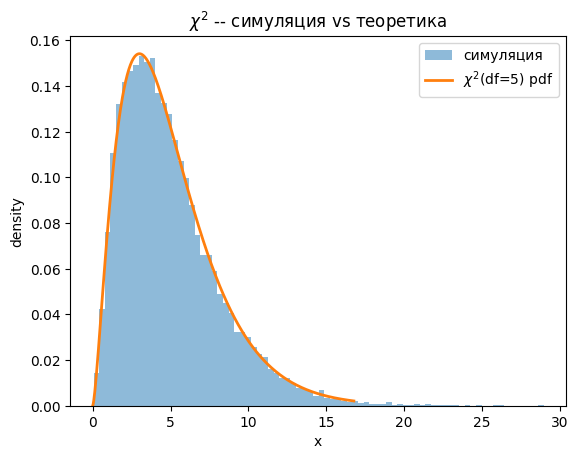

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

np.random.seed(0)
k = 5
B = 20000
# симулируем сумму квадратов k стандартных нормалей
chis = np.sum(np.random.normal(size=(B, k))**2, axis=1)

# гистограмма и теоретическая плотность
xs = np.linspace(0, np.percentile(chis, 99.5), 500)
plt.hist(chis, bins=80, density=True, alpha=0.5, label='симуляция')
plt.plot(xs, chi2.pdf(xs, df=k), label=f'$\chi^2$(df={k}) pdf', lw=2)
plt.legend(); plt.xlabel('x'); plt.ylabel('density'); plt.title('$\chi^2$ -- симуляция vs теоретика')
plt.show()

Распределение Стьюдента (t)

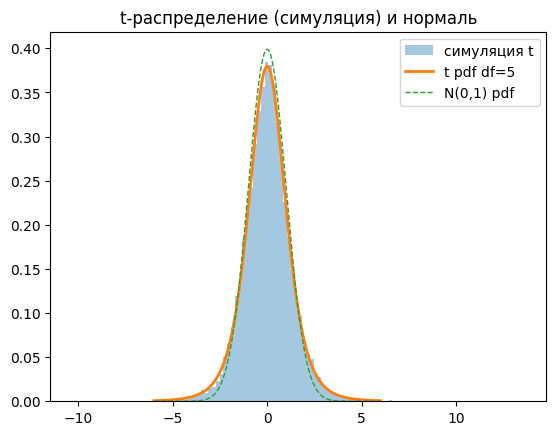

In [15]:
from scipy.stats import t, norm

np.random.seed(1)
df = 5
B = 20000
# симуляция t как ratio
z = np.random.normal(size=B)
chi = np.sum(np.random.normal(size=(B, df))**2, axis=1)
t_sim = z / np.sqrt(chi/df)

xs = np.linspace(-6, 6, 400)
plt.hist(t_sim, bins=120, density=True, alpha=0.4, label='симуляция t')
plt.plot(xs, t.pdf(xs, df), label=f't pdf df={df}', lw=2)
plt.plot(xs, norm.pdf(xs), label='N(0,1) pdf', lw=1, ls='--')
plt.legend(); plt.title('t-распределение (симуляция) и нормаль'); plt.show()

Распределение Фишера (F)

In [16]:
from scipy.stats import f

np.random.seed(2)
n1, n2 = 30, 40
# симуляция нормальных выборок с разными дисперсиями
s1 = np.random.normal(loc=0, scale=1.2, size=n1)
s2 = np.random.normal(loc=0, scale=0.9, size=n2)

var1 = s1.var(ddof=1)
var2 = s2.var(ddof=1)
F_stat = var1 / var2
df1, df2 = n1-1, n2-1
p_upper = 1 - f.cdf(F_stat, df1, df2)
p_two_sided = 2 * min(p_upper, 1-p_upper)  # грубая двухсторонняя версия
print(f"F = {F_stat:.3f}, df1={df1}, df2={df2}, one-sided p = {p_upper:.4f}, approx two-sided p={p_two_sided:.4f}")

F = 1.625, df1=29, df2=39, one-sided p = 0.0782, approx two-sided p=0.1565


In [18]:
import numpy as np

np.random.seed(251)
sample1 = np.random.normal(loc=0, scale=1.5, size=25)
sample2 = np.random.normal(loc=0, scale=1, size=30)
s21 = np.var(sample1, ddof=1)
s22 = np.var(sample2, ddof=1)
s21/s22



np.float64(2.031065726383414)

Симуляция ошибок I/II рода и мощности

In [1]:
import numpy as np
from scipy.stats import norm

def z_test_reject(x, mu0=0.0, sigma=1.0, alpha=0.05):
    n = len(x)
    z = (x.mean() - mu0) / (sigma/np.sqrt(n))
    crit = norm.ppf(1-alpha/2)
    return abs(z) > crit

def estimate_power(mu0=0.0, mu1=0.3, sigma=1.0, n=50, alpha=0.05, B=2000, seed=1):
    rng = np.random.default_rng(seed)
    rejects = 0
    for _ in range(B):
        x = rng.normal(loc=mu1, scale=sigma, size=n)
        if z_test_reject(x, mu0=mu0, sigma=sigma, alpha=alpha):
            rejects += 1
    return rejects / B

print("Estimated power (mu1=0.3, n=50):", estimate_power(mu1=0.3, n=50))

Estimated power (mu1=0.3, n=50): 0.5445


In [ ]:
estimate_power(mu1=0.5, n=50)

t-test (scipy) и сравнение с permutation test

In [ ]:
import numpy as np
from scipy.stats import norm

def z_test_reject(x, mu0=0.0, sigma=1.0, alpha=0.05):
    n = len(x)
    z = (x.mean() - mu0) / (sigma/np.sqrt(n))
    crit = norm.ppf(1-alpha/2)
    return abs(z) > crit

def estimate_power(mu0=0.0, mu1=0.3, sigma=1.0, n=50, alpha=0.05, B=2000, seed=1):
    rng = np.random.default_rng(seed)
    rejects = 0
    for _ in range(B):
        x = rng.normal(loc=mu1, scale=sigma, size=n)
        if z_test_reject(x, mu0=mu0, sigma=sigma, alpha=alpha):
            rejects += 1
    return rejects / B

print("Estimated power (mu1=0.3, n=50):", estimate_power(mu1=0.3, n=50))
def perm_test_mean(a, b):   
    pooled = np.concatenate([a, b])
    count = 0
    for _ in range(B):
        rng.shuffle(pooled)
        new_a = pooled[:len(a)]
        new_b = pooled[len(a):]
        if abs(new_a.mean() - new_b.mean()) >= abs(obs):
            count += 1
    return count / B

print("Permutation p:", perm_test_mean(a, b))

Estimated power (mu1=0.3, n=50): 0.5445


ValueError: zero-dimensional arrays cannot be concatenated

chi2 -тест независимости (contingency table)

In [6]:
import numpy as np
from scipy.stats import chi2_contingency

# таблица: строки -- лечение/контроль, столбцы -- успех/неуспех
table = np.array([[30, 70],
                  [20, 80]])
chi2, p, dof, ex = chi2_contingency(table)
print("chi2:", chi2, "p:", p, "expected:", ex)

chi2: 2.16 p: 0.14164469029513255 expected: [[25. 75.]
 [25. 75.]]


In [7]:
from scipy.stats import norm
def required_n_z(alpha=0.05, power=0.8, delta=0.3):
    z_a = norm.ppf(1-alpha/2)
    z_b = norm.ppf(power)
    return ((z_a + z_b) / delta)**2

print("n needed (delta=0.3):", int(np.ceil(required_n_z(delta=0.3))))

n needed (delta=0.3): 88


In [8]:
import numpy as np
from scipy.stats import norm, t, ttest_1samp

n=25; xbar=5.2; sigma=1.1; mu0=5.0
z = (xbar-mu0)/(sigma/np.sqrt(n))
p_two = 2*(1-norm.cdf(abs(z)))
z, p_two

(np.float64(0.9090909090909097), np.float64(0.3633021408868977))

In [9]:
from scipy.stats import binomtest
res = binomtest(k, n, p=p0, alternative='two-sided')
res.pvalue

NameError: name 'k' is not defined

In [10]:
import statsmodels.stats.proportion as smp
smp.proportion_confint(count=k, nobs=n, alpha=0.05, method='wilson')
smp.proportion_confint(count=k, nobs=n, alpha=0.05, method='beta')  # Clopper-Pearson

ModuleNotFoundError: No module named 'statsmodels'

In [11]:
import numpy as np
from scipy.stats import norm, t, ttest_1samp

# пример: sigma известно
n=50; xbar=125.8; sigma=10
z = (xbar-125)/(sigma/np.sqrt(n))
p_two = 2*(1-norm.cdf(abs(z)))

# пример: sigma неизвестен
data = np.random.normal(loc=0.3, scale=1.2, size=25)
tstat, pval = ttest_1samp(data, popmean=0.0)

In [12]:
import numpy as np
from scipy.stats import norm, t, ttest_1samp

# пример: sigma известно
n=50; xbar=125.8; sigma=10
z = (xbar-125)/(sigma/np.sqrt(n))
p_two = 2*(1-norm.cdf(abs(z)))

# пример: sigma неизвестен
data = np.random.normal(loc=0.3, scale=1.2, size=25)
tstat, pval = ttest_1samp(data, popmean=0.0)

Goodness-of-fit — пример: тест на соответствие распределению Пуассона

In [13]:
import numpy as np
from scipy.stats import chisquare, poisson
import math

np.random.seed(0)
n = 300
lam_true = 2.3
data = np.random.poisson(lam_true, size=n)

# группируем по значениям 0,1,...,max и объединяем хвост
max_k = data.max()
bins = list(range(0, max_k)) + [max_k+1]
values, counts = np.unique(data, return_counts=True)

# оценка lambda
lam_hat = data.mean()
probs = [poisson.pmf(k, lam_hat) for k in range(0, max_k)]
prob_tail = 1 - sum(probs)
probs.append(prob_tail)

E = np.array([p * n for p in probs])
O = np.array([counts[k] if k in values else 0 for k in range(0, max_k)] + [sum(counts[values>=max_k])])

# df = k_bins - 1 - m (m=1 параметр)
k_bins = len(O)
df = k_bins - 1 - 1

chi2_stat = ((O - E)**2 / E).sum()
from scipy.stats import chi2
pval = 1 - chi2.cdf(chi2_stat, df)
print("O:", O)
print("E:", np.round(E,2))
print("chi2 stat:", chi2_stat, "df:", df, "p-value:", pval)

O: [25 82 79 54 32 16  7  3  0  2]
E: [29.98 69.05 79.52 61.05 35.16 16.2   6.22  2.05  0.59  0.19]
chi2 stat: 22.260341083701125 df: 8 p-value: 0.004455742458216783


Contingency table — тест независимости

In [15]:
import numpy as np
from scipy.stats import chi2_contingency

table = np.array([[30, 20],
                  [10, 40],
                  [25, 15]])
chi2, p, dof, expected = chi2_contingency(table, correction=False)
print("chi2:", chi2, "p:", p, "dof:", dof)
print("expected:\n", expected)
#Монте-Карло p-value для малых ожидаемых частот
def monte_carlo_chi2_pvalue(observed_counts, expected_probs, B=5000, seed=0):
    rng = np.random.default_rng(seed)
    n = observed_counts.sum()
    obs_stat = (((observed_counts - expected_probs*n)**2) / (expected_probs*n)).sum()
    stats = np.empty(B)
    for i in range(B):
        samp = rng.multinomial(n, expected_probs)
        stats[i] = (((samp - expected_probs*n)**2) / (expected_probs*n)).sum()
    return (stats >= obs_stat).mean(), obs_stat

p_mc, obs_stat = monte_carlo_chi2_pvalue(O, np.array(probs), B=5000)
print("Monte Carlo p-value:", p_mc, "obs stat:", obs_stat)

chi2: 21.897435897435894 p: 1.7580540012965576e-05 dof: 2
expected:
 [[23.21428571 26.78571429]
 [23.21428571 26.78571429]
 [18.57142857 21.42857143]]
Monte Carlo p-value: 0.0212 obs stat: 22.260341083701125
